# Load image and add offset

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load coins.png as grayscale
img = cv2.imread("coins.png", cv2.IMREAD_GRAYSCALE)

# Add constant offset of 20
# Clip values to maximum intensity 255
offset = 20

offset_img = np.clip(img.astype(np.int16) + offset, 0, 255).astype(np.uint8)

print("Original minimum intensity:", img.min())
print("Original maximum intensity:", img.max())

print("After adding offset:")
print("New minimum intensity:", offset_img.min())
print("New maximum intensity:", offset_img.max())

# Number of pixels that were clipped at 255
clipped_pixels = np.sum((img.astype(np.int16) + offset) > 255)

print("Number of clipped pixels:", clipped_pixels)

Original minimum intensity: 11
Original maximum intensity: 255
After adding offset:
New minimum intensity: 31
New maximum intensity: 255
Number of clipped pixels: 439


# Compute Otsu threshold

In [2]:
hist = np.bincount(offset_img.ravel(), minlength=256)

total_pixels = offset_img.size
intensities = np.arange(256)

# Total weighted sum of intensities
total_sum = np.sum(intensities * hist)

weight_background = 0
sum_background = 0

min_variance = np.inf
optimal_threshold = 0

within_class_variances = []

for t in range(256):

    # Add pixels at intensity t to Class 0
    weight_background += hist[t]
    sum_background += t * hist[t]

    if weight_background == 0:
        within_class_variances.append(np.nan)
        continue

    # Number of pixels in Class 1
    weight_foreground = total_pixels - weight_background

    if weight_foreground == 0:
        within_class_variances.append(np.nan)
        continue

    # Class probabilities
    w0 = weight_background / total_pixels
    w1 = weight_foreground / total_pixels

    # Class means
    mean0 = sum_background / weight_background

    sum_foreground = total_sum - sum_background
    mean1 = sum_foreground / weight_foreground

    # Histogram values for each class
    class0_values = np.arange(t + 1)
    class0_hist = hist[:t + 1]

    class1_values = np.arange(t + 1, 256)
    class1_hist = hist[t + 1:]

    # Class variances
    variance0 = (
        np.sum(class0_hist * (class0_values - mean0) ** 2)
        / weight_background
    )

    variance1 = (
        np.sum(class1_hist * (class1_values - mean1) ** 2)
        / weight_foreground
    )

    # Within-class variance
    intra_variance = w0 * variance0 + w1 * variance1

    within_class_variances.append(intra_variance)

    # Find minimum
    if intra_variance < min_variance:
        min_variance = intra_variance
        optimal_threshold = t

print("====================================")
print("Otsu Result for Offset Image")
print("====================================")
print("Original Otsu Threshold =", 125)
print("Expected Threshold (125 + 20) =", 145)
print("Computed Otsu Threshold =", optimal_threshold)
print("Minimum Within-Class Variance =", min_variance)

Otsu Result for Offset Image
Original Otsu Threshold = 125
Expected Threshold (125 + 20) = 145
Computed Otsu Threshold = 145
Minimum Within-Class Variance = 255.93054363922528


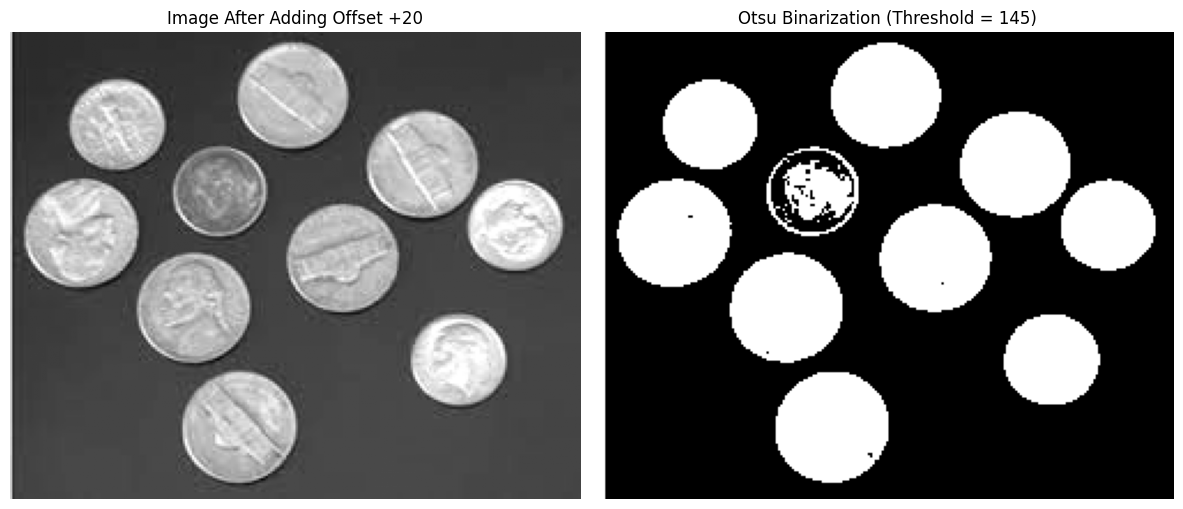

In [3]:
# Binarize the Offset Image

binary_offset = np.where(
    offset_img > optimal_threshold,
    255,
    0
).astype(np.uint8)

plt.figure(figsize=(12, 5))

# Offset image
plt.subplot(1, 2, 1)
plt.imshow(offset_img, cmap="gray")
plt.title("Image After Adding Offset +20")
plt.axis("off")

# Binarized image
plt.subplot(1, 2, 2)
plt.imshow(binary_offset, cmap="gray")
plt.title(f"Otsu Binarization (Threshold = {optimal_threshold})")
plt.axis("off")

plt.tight_layout()
plt.show()

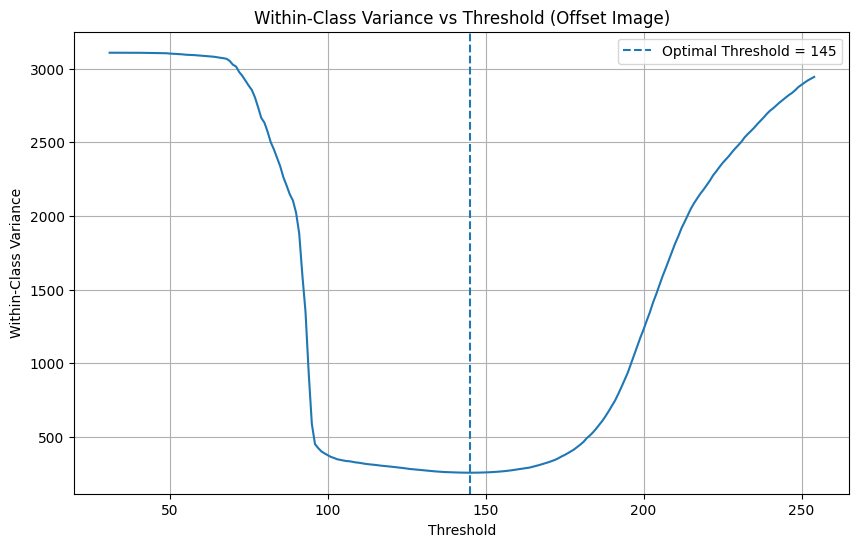

In [4]:
# Plot Within-Class Variance vs Threshold

plt.figure(figsize=(10, 6))

plt.plot(range(256), within_class_variances)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal Threshold = {optimal_threshold}"
)

plt.xlabel("Threshold")
plt.ylabel("Within-Class Variance")
plt.title("Within-Class Variance vs Threshold (Offset Image)")
plt.legend()
plt.grid(True)

plt.show()

# Original vs Offset Histogram

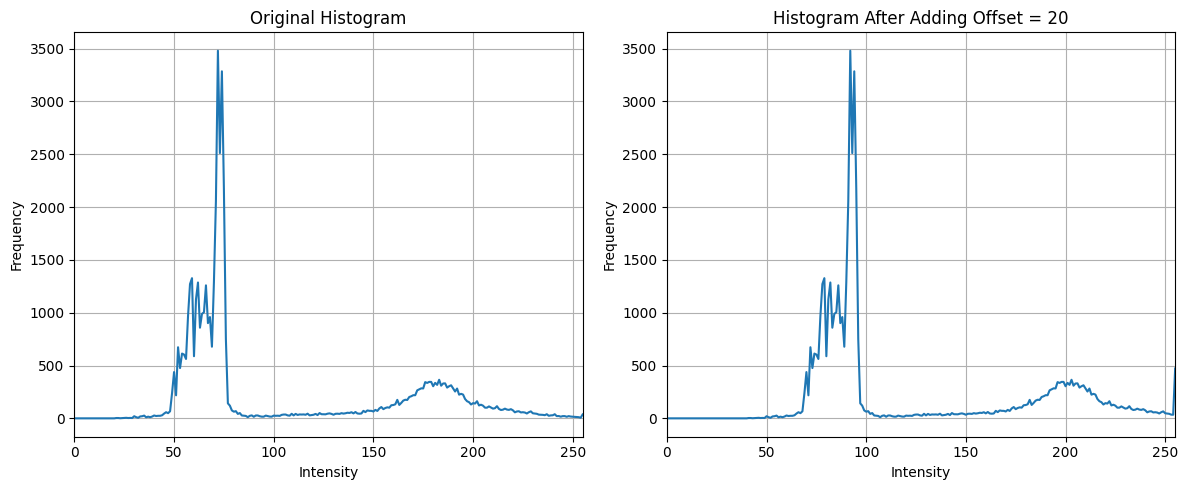

In [5]:
# Compute histograms
hist_original = np.bincount(img.ravel(), minlength=256)
hist_offset = np.bincount(offset_img.ravel(), minlength=256)

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(256), hist_original)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim(0, 255)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(256), hist_offset)
plt.title("Histogram After Adding Offset = 20")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim(0, 255)
plt.grid()

plt.tight_layout()
plt.show()

# Within-Class Variance Comparison

Original Image
------------------------------
Optimal Otsu Threshold = 125
Minimum Within-Class Variance = 265.1024571148033

Offset Image (+20)
------------------------------
Optimal Otsu Threshold = 145
Minimum Within-Class Variance = 255.93054363922528

Threshold Change = 20


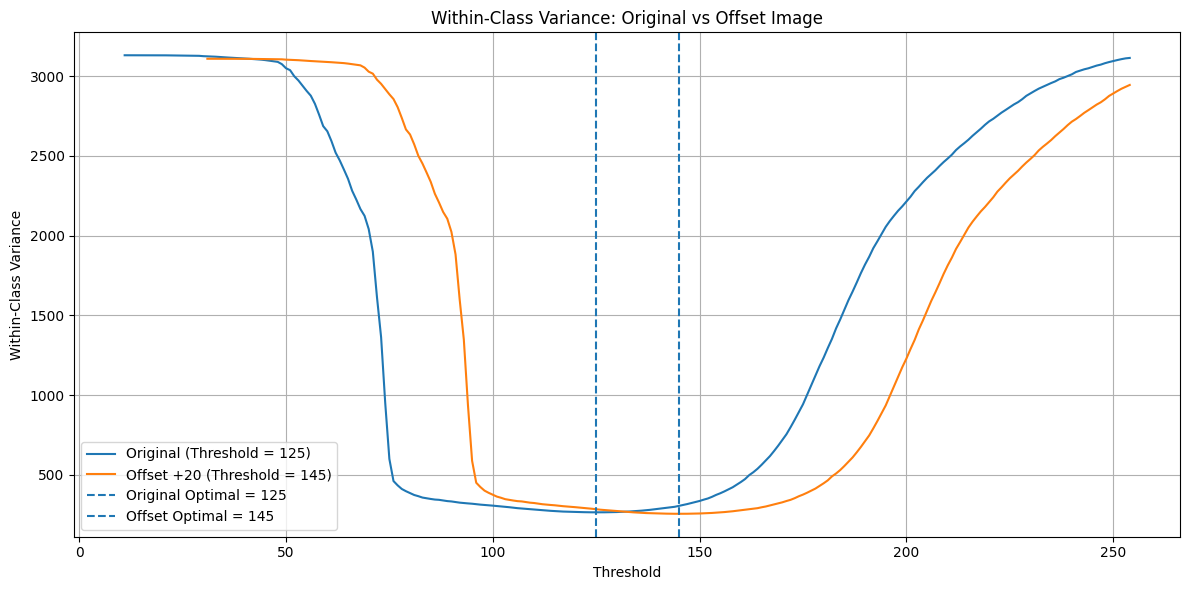

In [7]:
def compute_within_class_variance(image):
    """
    Compute Otsu's within-class variance for every threshold.
    """

    hist = np.bincount(image.ravel(), minlength=256).astype(np.float64)

    total_pixels = image.size

    # Probability of each intensity
    probabilities = hist / total_pixels

    thresholds = []
    within_variances = []

    for t in range(1, 255):

        # Class 0: intensities <= t
        w0 = np.sum(probabilities[:t+1])

        # Class 1: intensities > t
        w1 = np.sum(probabilities[t+1:])

        # Skip if one class is empty
        if w0 == 0 or w1 == 0:
            continue

        # Mean of class 0
        intensities0 = np.arange(t + 1)
        mean0 = np.sum(intensities0 * probabilities[:t+1]) / w0

        # Mean of class 1
        intensities1 = np.arange(t + 1, 256)
        mean1 = np.sum(intensities1 * probabilities[t+1:]) / w1

        # Variance of class 0
        variance0 = np.sum(
            ((intensities0 - mean0) ** 2) * probabilities[:t+1]
        ) / w0

        # Variance of class 1
        variance1 = np.sum(
            ((intensities1 - mean1) ** 2) * probabilities[t+1:]
        ) / w1

        # Otsu's within-class variance
        sigma_intra = w0 * variance0 + w1 * variance1

        thresholds.append(t)
        within_variances.append(sigma_intra)

    return np.array(thresholds), np.array(within_variances)


# Compute within-class variance for original image
thresholds_original, variance_original = compute_within_class_variance(img)

# Compute within-class variance for offset image
thresholds_offset, variance_offset = compute_within_class_variance(offset_img)

# Find optimal thresholds
optimal_original = thresholds_original[np.argmin(variance_original)]
minimum_original = np.min(variance_original)

optimal_offset = thresholds_offset[np.argmin(variance_offset)]
minimum_offset = np.min(variance_offset)

print("Original Image")
print("------------------------------")
print("Optimal Otsu Threshold =", optimal_original)
print("Minimum Within-Class Variance =", minimum_original)

print("\nOffset Image (+20)")
print("------------------------------")
print("Optimal Otsu Threshold =", optimal_offset)
print("Minimum Within-Class Variance =", minimum_offset)

print("\nThreshold Change =", optimal_offset - optimal_original)


# Plot within-class variance
plt.figure(figsize=(12, 6))

plt.plot(
    thresholds_original,
    variance_original,
    label=f"Original (Threshold = {optimal_original})"
)

plt.plot(
    thresholds_offset,
    variance_offset,
    label=f"Offset +20 (Threshold = {optimal_offset})"
)

plt.axvline(
    optimal_original,
    linestyle="--",
    label=f"Original Optimal = {optimal_original}"
)

plt.axvline(
    optimal_offset,
    linestyle="--",
    label=f"Offset Optimal = {optimal_offset}"
)

plt.xlabel("Threshold")
plt.ylabel("Within-Class Variance")
plt.title("Within-Class Variance: Original vs Offset Image")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()